# 07 — Reinforcement Learning: From Optimal Control to Learning

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

Classical control steers a system whose equations of motion are known. In this notebook, we remove that assumption. Instead, we interact with the system and observe its state and reward or cost at each time step.

### Table of Contents

1. **A short history** — the law of effect, Bellman at RAND, and what happened after
2. **Two vocabularies for one problem** — optimal control and reinforcement learning side by side
3. **The Bellman equation** — a contraction, and therefore an algorithm
4. **From control to RL** — Q-learning, and a note on dopamine
5. **Exploration versus exploitation** — bandits, on-policy and off-policy
6. **Pontryagin's maximum principle** — the adjoint, direct shooting, and a trip to the Moon
7. **Markov decision processes** — the probabilistic setting
8. **The policy gradient theorem** — and REINFORCE on a problem whose answer we know
9. **PPO** — a pendulum that teaches itself to swing up


In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.distributions import Normal
import plotting as P           # the course palette, the house style, and the figure helpers

rng = np.random.default_rng(0)
torch.manual_seed(0);

## 1. A short history

**Idea.** Reinforcement learning connects behavioral experiments to sequential decision-making.

In 1898 [Edward Thorndike](https://psychclassics.yorku.ca/Thorndike/Animal/) put cats in puzzle boxes and
timed how long they took to escape. The times fell with repetition, and from this he formulated the **law of
effect**: responses followed by satisfaction become more likely, responses followed by discomfort less so.
[Pavlov](https://www.nobelprize.org/prizes/medicine/1904/pavlov/facts/) showed around the same time that
dogs can be conditioned to anticipate a stimulus, and in the 1930s
[B. F. Skinner](https://doi.org/10.1037/h0058412) made the shaping of voluntary behavior by reinforcement
into an experimental science. None of this was mathematics, but it fixed the vocabulary — *state*,
*action*, *reward* — that the mathematics would later use.

The mathematics arrived from a different direction. In the early 1950s
[Richard Bellman](https://doi.org/10.1073/pnas.38.8.716) was at RAND working for the U.S. Air Force on
multi-stage decisions under uncertainty: how many aircraft to commit at each stage of a mission. The method
he found — solve the last stage first, then work backwards — he called **dynamic programming**, reportedly
because "programming" sounded respectable to his sponsors and "dynamic" was impossible to use pejoratively.
Out of it came the equation that carries his name, the recognition that it is a fixed-point problem, and
the phrase **curse of dimensionality** for the reason you cannot simply solve it on a grid. By the end of
the decade he had pushed it into continuous time (Appendix A), where it generalizes the Hamilton–Jacobi equation of the
1830s. In parallel, [Pontryagin's group](https://www.mathnet.ru/eng/im3547) in Moscow was deriving necessary
conditions for optimal missile trajectories, and [Kalman](https://liberzon.csl.illinois.edu/teaching/kalman_paper.pdf)
was writing down the LQR of notebook 02.

Learning and control met in the late 1980s. [Sutton's temporal-difference methods](https://doi.org/10.1007/BF00115009)
treated the Bellman equation as something to be satisfied *on average along sampled trajectories*;
[Watkins' Q-learning](https://doi.org/10.1007/BF00992698) made that idea converge to the optimal value
without ever estimating the dynamics. [Williams](https://doi.org/10.1007/BF00992696) showed that one can
differentiate the expected return of a stochastic policy using nothing but rollouts. Then in 1997
[Schultz, Dayan and Montague](https://doi.org/10.1126/science.275.5306.1593) reported that midbrain
dopamine neurons fire in proportion to a *reward-prediction error* — the same quantity $\delta_t$ that sits
inside the Q-learning update. The observation suggests a connection between temporal-difference learning and biological reward signals.

What followed is mostly a story of function approximation: [TD-Gammon](https://doi.org/10.1145/203330.203343)
(described in Tesauro’s 1995 article), [DQN on Atari](https://doi.org/10.1038/nature14236) in 2015, [AlphaGo](https://doi.org/10.1038/nature16961)
in 2016, [PPO](https://arxiv.org/abs/1707.06347) in 2017, and the use of policy gradients to
align language models with human preferences ([Ouyang et al., 2022](https://arxiv.org/abs/2203.02155)).

![Timeline of optimal control and reinforcement learning, from Euler's variational calculus and Thorndike's law of effect to PPO and GRPO](images/rl_history_timeline.png)

## 2. Two vocabularies for one problem

**Idea.** Control and RL share states, actions, dynamics, and an objective.

Control theory and reinforcement learning describe the same object with different letters. The table below
is a dictionary; it is worth reading once carefully, because every formula later in the notebook can be
written in either column.

| Concept | Optimal control | Reinforcement learning |
|---|---|---|
| State | $x_t \in \mathcal{X}$ | $s_t \in \mathcal{S}$ |
| Action | $u_t \in \mathcal{U}$ | $a_t \in \mathcal{A}$ |
| Dynamics | $x_{t+1} = f(x_t, u_t)$ | $s_{t+1} \sim P(\cdot \mid s_t, a_t)$ |
| Decision rule | control signal $u_t$ | policy $a_t \sim \pi(\cdot\mid s_t)$ |
| Running objective | cost $\ell(x_t, u_t)$ | reward $r(s_t, a_t)$ |
| Total objective | $J(x) = \inf_{u(\cdot)} \sum_{t\ge 0} \gamma^t \ell(x_t,u_t)$ | $V(s) = \sup_{\pi} \mathbb{E}\big[\sum_{t\ge 0}\gamma^t r(s_t,a_t)\big]$ |
| Model | $f$ and $\ell$ are **known** | $f$ and $r$ are **unknown** |

The last row describes the distinction used in this notebook: a known model versus learning from interaction. More generally, control can use learned models, and RL can use known ones. The sign in the second-to-last row is a convention: a reward can be defined as the negative of a cost. We will use the control letters $x, u$ while the model is known, and switch
to $s, a$.

Three examples show how wide the setting is.

| | **Chess** | **LQR** | **Heat equation** |
|---|---|---|---|
| State space | legal positions, $\lvert\mathcal{X}\rvert \approx 10^{43}$ | $x \in \mathbb{R}^n$ | $y(t,\cdot) \in L^2(\Omega)$ |
| Action space | legal moves at $x$ | $u \in \mathbb{R}^m$ | $u(t,\cdot)$ supported on $\omega \subset \Omega$ |
| Dynamics | $x_{t+1} = f(x_t,u_t)$, deterministic | $\dot x = Ax + Bu$ | $\partial_t y = \Delta y + u \mathbf{1}_\omega$ |
| Objective | $\pm 1$ at checkmate, $0$ otherwise | $\int_0^\infty x^\top Q x + u^\top R u \, dt$ | $\int_0^\infty \lVert y - y^\star\rVert^2 + \lVert u\rVert^2 dt$ |
| Difficulty | finite but astronomically large | solved in closed form | infinite-dimensional |

## 3. The Bellman equation

**Idea.** Separate the first decision from the remaining decisions.

Assume bounded rewards and a finite action set, so the maxima below are attained. Fix a deterministic system and an infinite horizon with discount $\gamma \in [0,1)$:

$$x_{t+1} = f(x_t, u_t), \qquad x_0 = x, \qquad V(x) := \sup_{u(\cdot)} \sum_{t=0}^\infty \gamma^t r(x_t, u_t).$$

> **Theorem ([Bellman, 1952](https://doi.org/10.1073/pnas.38.8.716)).** The value function satisfies
>
> $$V(x) = \max_{u \in \mathcal{U}} \big\{ r(x,u) + \gamma\, V\big(f(x,u)\big) \big\},$$
>
> and the policy $\pi^\star(x) \in \arg\max_u \{ r(x,u) + \gamma V(f(x,u))\}$ is optimal.

*Proof.* Split the control sequence as $u = (u_0, u^+)$ with $u^+ = (u_1, u_2, \dots)$. Then

$$
\begin{aligned}
V(x) &= \sup_{u} \sum_{t\ge 0} \gamma^t r(x_t,u_t) \\
     &= \max_{u_0} \sup_{u^+} \Big\{ r(x,u_0) + \gamma \sum_{t\ge 0}\gamma^{t} r(x_{t+1},u_{t+1}) \Big\} \\
     &= \max_{u_0} \Big\{ r(x,u_0) + \gamma \sup_{u^+} \sum_{t \ge 0}\gamma^{t} r(x_{t+1},u_{t+1}) \Big\} \\
     &= \max_{u_0} \big\{ r(x,u_0) + \gamma V\big(f(x,u_0)\big) \big\}.
\end{aligned}
$$

The third equality is the whole content of the argument: $r(x,u_0)$ does not depend on $u^+$, so it leaves
the inner supremum, and what remains is by definition the value of the state $f(x,u_0)$. This is the
**principle of optimality**.

### A contraction, and therefore an algorithm

Define the **Bellman operator** on bounded functions $V : \mathcal{X} \to \mathbb{R}$,

$$(\mathcal{T}V)(x) := \max_{u \in \mathcal{U}} \big\{ r(x,u) + \gamma\, V(f(x,u)) \big\}.$$

> **Theorem.** $\mathcal{T}$ is a $\gamma$-contraction in the supremum norm: $\lVert \mathcal{T}V - \mathcal{T}W \rVert_\infty \le \gamma \lVert V - W \rVert_\infty$.

*Proof.* Fix $x$ and use $\lvert \max_u F_u - \max_u G_u \rvert \le \max_u \lvert F_u - G_u \rvert$:

$$\lvert (\mathcal{T}V)(x) - (\mathcal{T}W)(x)\rvert \le \max_u \gamma \big\lvert V(f(x,u)) - W(f(x,u)) \big\rvert \le \gamma \lVert V - W\rVert_\infty. \qquad \square$$

By the Banach fixed-point theorem $V^\star$ is the *unique* bounded solution of $\mathcal{T}V = V$, and
**value iteration** $V_{k+1} = \mathcal{T}V_k$ converges from any starting point:

$$\lVert V_k - V^\star \rVert_\infty \le \gamma^k \lVert V_0 - V^\star\rVert_\infty,
\qquad \lVert V_k - V^\star \rVert_\infty \le \frac{\gamma}{1-\gamma}\,\lVert V_k - V_{k-1}\rVert_\infty .$$

The second bound is computable, so it is the one used as a stopping rule. Note what the theorem costs:
one sweep evaluates every pair $(x,u)$, i.e. $\mathcal{O}(\lvert\mathcal{X}\rvert\lvert\mathcal{U}\rvert)$
work, *and it needs $f$ and $r$*. For chess that is $10^{43}$ states; this is Bellman's curse of
dimensionality, and it is the reason the rest of the notebook exists.

> **Example: Maze**
> The environment is a grid with walls, an absorbing goal $\mathsf{G}$ worth $+1$. Four actions; walking into a wall leaves the state unchanged. Every other transition has reward zero, so for a nonterminal state $V^\star(x) = \gamma^{\,d(x)-1}$, where $d(x)$ is the length of the shortest route to the goal. The goal itself has value zero in the code. The discounting alone is what makes the agent hurry.

**Code and plot.** Run value iteration on a maze. Watch value propagate back from the goal.

In [2]:
MAZE = np.array([list(row) for row in [
    "S........", ".........", "..#####..", "..#...#..",
    "..#.#.#..", "....#....", ".#####.#.", "........G"]])
MOVES = np.array([[-1, 0], [1, 0], [0, -1], [0, 1]])      # up, down, left, right
GAMMA, (H, W) = 0.95, MAZE.shape

free = np.argwhere(MAZE != "#")                           # the state space: the non-wall cells
idx = -np.ones((H, W), int); idx[tuple(free.T)] = np.arange(len(free))
term = MAZE[tuple(free.T)] == "G"                         # absorbing state
nb = np.clip(free[:, None] + MOVES, 0, [H - 1, W - 1])    # candidate next cells, (n_states, 4, 2)
wall = idx[nb[..., 0], nb[..., 1]] < 0
NEXT = np.where(wall, np.arange(len(free))[:, None], idx[nb[..., 0], nb[..., 1]])     # f(x, u)
tgt = MAZE[nb[..., 0], nb[..., 1]]
R = (tgt == "G").astype(float)                            # r(x, u)

In [3]:
def bellman(V):                                           # one application of the operator T
    return np.where(term, 0.0, (R + GAMMA * V[NEXT]).max(1))

V, hist = rng.random(len(free)), []
for k in range(120):
    hist.append(V); V = bellman(V)
V_star = V
print(f"fixed-point residual ||TV* - V*||_inf = {np.abs(bellman(V_star) - V_star).max():.2e}")

fixed-point residual ||TV* - V*||_inf = 0.00e+00


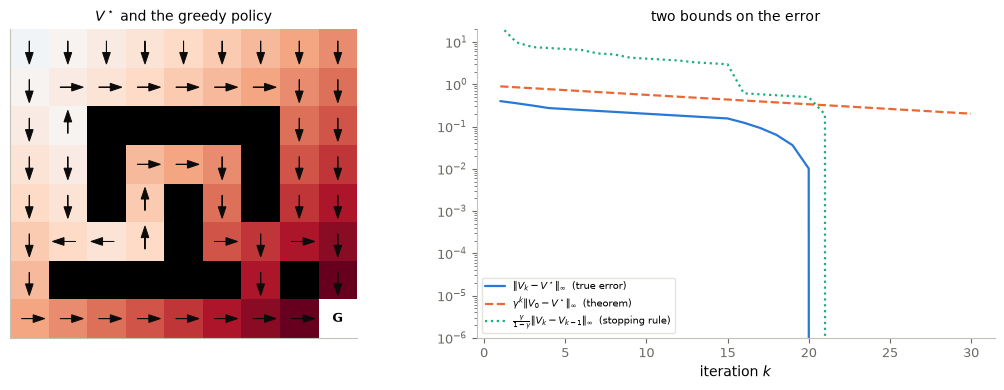

In [4]:
err = np.array([np.abs(v - V_star).max() for v in hist])
pi_star = (R + GAMMA * V_star[NEXT]).argmax(1)            # the greedy policy

def draw_values(ax, V, policy, **kw):                     # the maze drawing lives in plotting.py
    return P.maze_values(ax, MAZE, free, term, MOVES, V, policy, **kw)

fig, (a0, a1) = P.panels(2, size=(5.5, 4))
draw_values(a0, V_star, pi_star, title=r"$V^\star$ and the greedy policy")
ks = np.arange(1, 31)
a1.semilogy(ks, err[ks], color=P.BLUE, label=r"$\|V_k - V^\star\|_\infty$  (true error)")
a1.semilogy(ks, GAMMA ** ks * err[0], "--", color=P.ORANGE,
            label=r"$\gamma^k\|V_0-V^\star\|_\infty$  (theorem)")
a1.semilogy(ks, GAMMA / (1 - GAMMA) * np.abs(np.diff(hist, axis=0)).max(1)[ks - 1], ":", color=P.AQUA,
            label=r"$\frac{\gamma}{1-\gamma}\|V_k-V_{k-1}\|_\infty$  (stopping rule)")
P.label(a1, "iteration $k$", ylim=(1e-6, 20), title="two bounds on the error",
      legend={"fontsize": 7, "loc": "lower left"})
plt.show()

In [5]:
V, frames = np.zeros(len(free)), []
for k in range(26):
    frames.append((V, (R + GAMMA * V[NEXT]).argmax(1))); V = bellman(V)

fig, ax = P.panels(figsize=(4.4, 4))
def draw(k):
    ax.clear(); draw_values(ax, *frames[k], title=f"value iteration, $k = {k}$")
P.animate(fig, draw, len(frames), interval=350)

## 4. From control to RL

**Idea.** Learn action values from the transitions you observe.

Everything so far assumed we could *evaluate* $f$ and $r$: value iteration asks for $r(x,u)$ and
$f(x,u)$ at every pair. Reinforcement learning drops that assumption. The agent can only act and observe:

- it sees a state $s_t$,
- it chooses an action $a_t \sim \pi(\cdot \mid s_t)$,
- it receives a reward $r_t$,
- it finds itself in a new state $s_{t+1}$.

What it collects is a stream of tuples $\{(s_t, a_t, r_t, s_{t+1})\}_t$ and nothing else. Two families of
algorithms grow out of this. **Value-based** methods estimate $V$ or $Q$ from the stream and read off a
policy greedily; **policy-based** methods parameterize $\pi_\theta$ and improve it directly. This section
and the next do the first; §8 and §9 do the second.

### Q-learning

The obstacle to using $V$ without a model is the $\max_u \{ r(x,u) + \gamma V(f(x,u))\}$: picking the
greedy action requires knowing where each action leads. So include the first action in the value function and define the
**action-value function**

$$Q(x,u) := r(x,u) + \gamma V\big(f(x,u)\big), \qquad\text{so that}\qquad V(x) = \max_{u} Q(x,u).$$

Substituting the second identity into the first eliminates $V$ entirely:

$$\boxed{\;Q(x,u) = r(x,u) + \gamma \max_{u'} Q\big(f(x,u), u'\big)\;}$$

and the greedy policy $\pi^\star(x) \in \arg\max_u Q^\star(x,u)$ is optimal — now computable from $Q$ alone.
The corresponding operator $(\mathcal{T}Q)(x,u) := r(x,u) + \gamma\max_{u'}Q(f(x,u),u')$ is again a
$\gamma$-contraction, by the same two lines as before, so $Q^\star$ exists and is unique.

This is still a model-based identity. The step that makes it an algorithm is to stop *solving* the equation
and start *correcting* towards it, one observed transition at a time. Given a sample
$(s_t, a_t, r_t, s_{t+1})$, form the **temporal-difference error**

$$\delta_t := \underbrace{r_t + \gamma \max_{a'} Q(s_{t+1},a')}_{\text{what the data say}} \;-\; \underbrace{Q(s_t,a_t)}_{\text{what we believed}},
\qquad Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha\,\delta_t .$$

$\delta_t$ is an unbiased sample of the Bellman residual at $(s_t,a_t)$, so the update is a stochastic
approximation to $Q \leftarrow \mathcal{T}Q$. [Watkins and Dayan (1992)](https://doi.org/10.1007/BF00992698)
proved it converges to $Q^\star$ with probability one, provided every state–action pair is visited
infinitely often and, for each state–action pair, the step sizes across its visits satisfy the Robbins–Monro conditions
$\sum_j \alpha_j = \infty$, $\sum_j \alpha_j^2 < \infty$. The first condition is not a technicality: it is
the whole subject of §5.

> **An aside on dopamine.** In 1997 [Schultz, Dayan and Montague](https://doi.org/10.1126/science.275.5306.1593)
> recorded midbrain dopamine neurons in monkeys. The neurons fired when an unexpected reward arrived; after
> a predictive cue was learned, they fired at the *cue* instead; and when an expected reward failed to
> appear, their activity *dipped below baseline* at exactly the moment it was due. That is the sign pattern
> of $\delta_t$, not of reward. The reward-prediction-error hypothesis — that dopamine broadcasts $\delta_t$
> — remains one of the closest contacts between a machine-learning algorithm and a measured biological
> signal.
>
> ![Dopamine neurons in the macaque basal ganglia: expected value in the caudate head, reward-prediction error in the putamen](images/dopamine_rpe.png)

Below, the same grid world as §3, but the agent is given only `NEXT` and `R` as an *oracle it may query at
its current state*: it never reads them as tables, never sweeps over the state space, and never sees a
transition it did not itself take.

**Code and plot.** Learn the same maze from sampled transitions and compare the error with value iteration.

In [6]:
start = np.flatnonzero(~term)                       # episodes begin anywhere, so every pair is reachable
Q, s, err_q = np.ones((len(free), 4)), rng.choice(start), []    # optimistic init: unseen actions look good

for t in range(60_000):
    a = rng.integers(4) if rng.random() < 0.1 else Q[s].argmax()          # epsilon-greedy
    s2, r = NEXT[s, a], R[s, a]                                           # the environment answers
    delta = r + GAMMA * (0.0 if term[s2] else Q[s2].max()) - Q[s, a]      # temporal-difference error
    Q[s, a] += 0.2 * delta
    s = rng.choice(start) if term[s2] else s2
    if t % 500 == 0:
        err_q.append(np.abs(np.where(term, 0, Q.max(1)) - V_star).max())

pi_q = Q.argmax(1)
print(f"||max_a Q - V*||_inf        = {err_q[-1]:.2e}")
print(f"sub-optimality of greedy pi = {np.abs(V_star - (R + GAMMA * V_star[NEXT])[np.arange(len(free)), pi_q])[~term].max():.2e}")

||max_a Q - V*||_inf        = 4.55e-06
sub-optimality of greedy pi = 0.00e+00


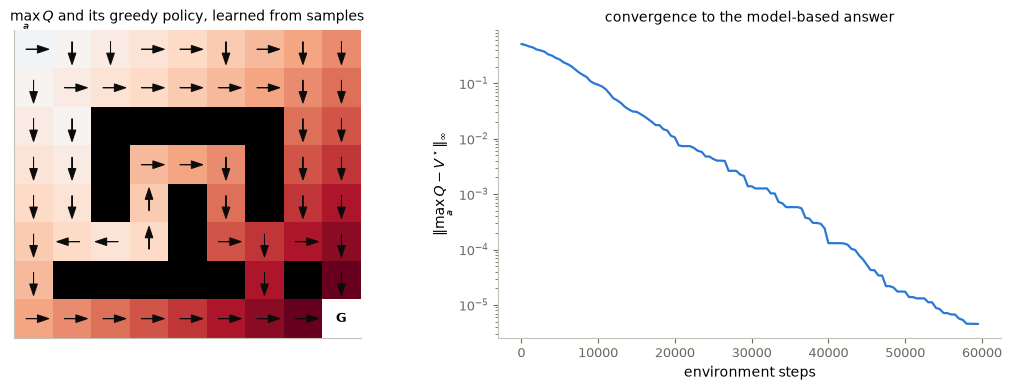

In [7]:
fig, (a0, a1) = P.panels(2, size=(5.5, 4))
draw_values(a0, np.where(term, 0, Q.max(1)), pi_q,
            title=r"$\max_a Q$ and its greedy policy, learned from samples")
P.curves(a1, np.arange(len(err_q)) * 500, err_q, log="y", xlabel="environment steps",
       ylabel=r"$\|\max_a Q - V^\star\|_\infty$",
       title="convergence to the model-based answer")
plt.show()

The learned value field is indistinguishable from the one value iteration computed with full knowledge of
$f$ and $r$, and the induced policy is exactly optimal (where the arrows differ, the two actions have equal
value). The price is on the horizontal axis. Value iteration settled in a couple of dozen sweeps; Q-learning
needed tens of thousands of steps of interaction to reach the same answer, and it had to *walk* to every
state it wanted to learn about. In dynamic programming the currency is computation; in reinforcement
learning it is experience.

Two details in the code carry weight. `Q = np.ones(...)` is *optimistic initialization*: since true values
are below $1$, any action never tried looks better than one already tried, and the agent sweeps its options
without being told to. Episodes restart from a uniformly random nonterminal state, and $\varepsilon$-greedy actions provide exploration. The fixed step size $0.2$ keeps this deterministic example short; it does not satisfy the diminishing-step-size conditions of the general convergence theorem. Without exploration, zero initialization and ties broken by index can leave the agent repeatedly choosing *up* against a wall.

## 5. Exploration versus exploitation

**Idea.** Try uncertain actions while still using what you have learned.

Watkins' theorem needs every state–action pair visited infinitely often, but the policy we are learning is
greedy, and a greedy policy visits what it already likes. The standard compromise is the
**$\varepsilon$-greedy** rule: behave greedily, except that with probability $\varepsilon$ act at random,

$$a_t \sim \begin{cases}\arg\max_{a} Q(s_t,a), & \text{with probability } 1-\varepsilon,\\[2pt]
\mathrm{Uniform}(\mathcal{A}), & \text{with probability } \varepsilon.\end{cases}$$

Both extremes fail. At $\varepsilon = 0$ the agent never revises a bad early estimate; at $\varepsilon = 1$
it keeps choosing random actions even after it has learned which actions are better. The cleanest place to see the trade-off is
the **multi-armed bandit** of [Robbins (1952)](https://doi.org/10.1090/S0002-9904-1952-09620-8): a single
state, $K$ actions, and reward $r(a) \sim \mathcal{N}(\mu_a, 1)$. Here the best expected reward per pull is $\max_a \mu_a$ and
$Q(a) \to \mu_a$ is just an average of samples, so nothing but the exploration question remains.

**Code and plot.** Compare reward and optimal-action frequency for several exploration rates.

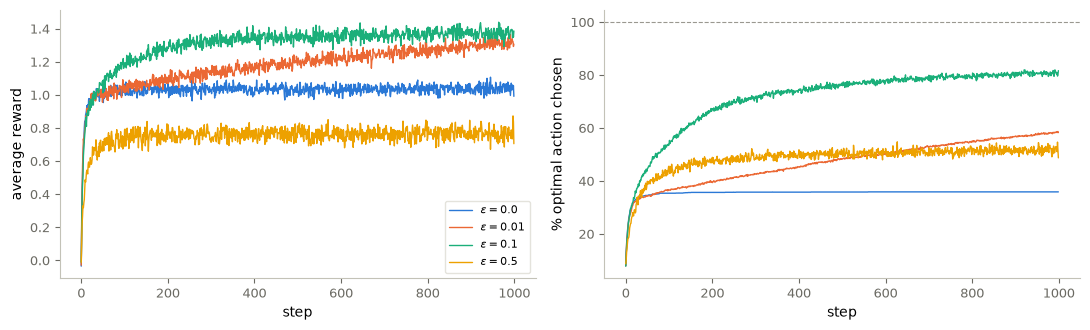

In [8]:
K, RUNS, STEPS = 10, 2000, 1000
mu = rng.standard_normal((RUNS, K))                      # one bandit instance per run
best, ix = mu.argmax(1), np.arange(RUNS)

def run_eps(eps):
    Q, N, out = np.zeros((RUNS, K)), np.zeros((RUNS, K)), np.zeros((STEPS, 2))
    for t in range(STEPS):
        a = np.where(rng.random(RUNS) < eps, rng.integers(K, size=RUNS), Q.argmax(1))
        r = mu[ix, a] + rng.standard_normal(RUNS)
        N[ix, a] += 1
        Q[ix, a] += (r - Q[ix, a]) / N[ix, a]             # running mean = step size 1/N
        out[t] = r.mean(), (a == best).mean()
    return out

fig, (a0, a1) = P.panels(2, size=(5.5, 3.4))
for eps in [0.0, 0.01, 0.1, 0.5]:
    out = run_eps(eps)
    a0.plot(out[:, 0], lw=1, label=rf"$\varepsilon = {eps}$"); a1.plot(100 * out[:, 1], lw=1)
a1.axhline(100, color=P.GREY, lw=0.8, ls="--")
P.label(a0, "step", "average reward")
P.label(a1, "step", "% optimal action chosen")
plt.show()

Pure greed ($\varepsilon = 0$) rises fastest for the first few pulls and then stops: it commits to whichever
arm happened to pay first, and after a thousand steps is still choosing the best arm only about a third of
the time. High exploration ($\varepsilon = 0.5$) does the opposite — it *finds* the best arm reliably and then
throws away half of its pulls on arms it knows are worse, so it earns the least of the four. The two panels
rank these two differently, which is the point: knowing which arm is best and actually playing it are
separate achievements, and $\varepsilon$ decides how much of one you trade for the other.

The useful values are small and positive, and the right one depends on the horizon: on a longer run
$\varepsilon = 0.01$ eventually overtakes $\varepsilon = 0.1$, which is why $\varepsilon$ is normally
annealed towards zero. Modern alternatives replace the uniform noise with something directed: optimism (UCB), posterior
sampling (Thompson), or an entropy bonus in the objective itself, which is the route PPO takes in §9.

### On-policy and off-policy

There are two policies in the room. The **behavior policy** $\mu$ generates the data; the **target
policy** $\pi$ is the one being improved. Q-learning's update uses $\max_{a'} Q(s_{t+1},a')$ — the value of
the *greedy* action — while the data was gathered by an $\varepsilon$-greedy walk. Target $\neq$ behavior,
so Q-learning is **off-policy**. Replacing that $\max$ by $Q(s_{t+1}, a_{t+1})$, the action actually taken
next, gives SARSA, which is **on-policy**.

| | **On-policy** ($\mu = \pi$) | **Off-policy** ($\mu \neq \pi$) |
|---|---|---|
| Examples | SARSA, REINFORCE, A2C, TRPO, PPO | Q-learning, DQN, DDPG, TD3, SAC |
| Data | usually fresh rollouts; PPO reuses a batch for several epochs | may be kept in a replay buffer and reused |
| Sample efficiency | low | high |
| Stability | more stable, simpler theory | can diverge — the *deadly triad* |

The **deadly triad** ([Sutton and Barto, 2018](https://mitpress.mit.edu/9780262039246/reinforcement-learning/)): bootstrapping, function approximation and off-policy data are each
harmless alone, and jointly can make the iteration diverge — the composition of a $\gamma$-contraction with
a projection onto the span of the features need not be a contraction in any norm. DQN's target networks and
replay buffers exist to make the composition behave.

## 6. Pontryagin's maximum principle

**Idea.** An adjoint tracks how changes along a trajectory affect the objective.

Dynamic programming is not the only route to optimality, and historically it was not the only one being
built. While Bellman was at RAND, [Lev Pontryagin's group](https://www.mathnet.ru/eng/im3547) in Moscow was
working on trajectory optimization for ballistic missiles, and arrived at necessary conditions of a
completely different shape: no value function on the state space, just two coupled ODEs along a single
trajectory.

![Lev Pontryagin](images/pontryagin.png)

Take a **finite horizon** and minimize

$$J(u) = \int_0^T \ell(x_t,u_t)\,dt + \ell_T(x_T), \qquad \dot x_t = f(x_t,u_t),\quad x_0 = x.$$

Introduce the **Hamiltonian** $H(x,u,p) := \ell(x,u) + p^\top f(x,u)$.

> **Theorem ([Pontryagin et al., 1962](https://www.routledge.com/The-Mathematical-Theory-of-Optimal-Processes/Pontryagin/p/book/9782881240775); normal, smooth case).** If $(x^\star, u^\star)$ is optimal, there is an *adjoint* (costate)
> $p : [0,T] \to \mathbb{R}^n$ with
>
> $$
> \begin{aligned}
> \dot x^\star_t &= \nabla_p H = f(x^\star_t, u^\star_t), & x^\star_0 &= x,\\
> \dot p_t &= -\nabla_x H = -\nabla_x \ell - (\nabla_x f)^\top p_t, & p_T &= \nabla \ell_T(x^\star_T),\\
> u^\star_t &= \arg\min_{u \in \mathcal{U}} H(x^\star_t, u, p_t). &&
> \end{aligned}
> $$

*Where the adjoint comes from.* Enforce the dynamics with a multiplier $p$ and integrate by parts:

$$\mathcal{L} = \int_0^T \ell\,dt + \ell_T(x_T) + \int_0^T p_t^\top(f - \dot x_t)\,dt,
\qquad \int_0^T p^\top \dot x\,dt = p_T^\top x_T - p_0^\top x_0 - \int_0^T \dot p^\top x\,dt .$$

The first variation, with $\delta x_0 = 0$, is

$$\delta\mathcal{L} = \int_0^T \big(\nabla_x \ell + (\nabla_x f)^\top p + \dot p\big)^\top \delta x\,dt
+ \int_0^T \big(\nabla_u \ell + (\nabla_u f)^\top p\big)^\top \delta u\,dt
+ \big(\nabla \ell_T(x_T) - p_T\big)^\top \delta x_T .$$

Choosing $p$ to annihilate the $\delta x$ terms gives the adjoint equation and its terminal condition, and
what is left multiplying $\delta u$ is the gradient: $\nabla_{u(t)}J = \nabla_u \ell + (\nabla_u f)^\top p_t$.
The multiplier is a sensitivity — when the value function is differentiable, $p_t = \nabla_x V(t, x^\star_t)$, which is how the two theories
touch. Here $V$ solves the Hamilton–Jacobi–Bellman equation, the continuous-time Bellman equation
derived in Appendix A, and the two routes compare as follows:

| | **HJB** | **PMP** |
|---|---|---|
| Unknown | $V(t,x)$ on $[0,T]\times\mathcal{X}$ | $(x^\star_t, p_t)$ on $[0,T]$ |
| Equation | a PDE on the state space | ODEs along one trajectory |
| Yields | a feedback law $u^\star(x)$ (closed loop) | a control signal $u^\star(t)$ (open loop) |
| Conditions | necessary **and** sufficient | necessary only |
| Cost | a state-space grid grows exponentially with dimension | trajectory computation grows with state dimension and horizon |

The last row is why PMP survives in high dimensions and HJB does not, and it is the reason trajectory
optimization and model predictive control are written this way.

### Direct shooting is reverse-mode autodiff

Discretise with Euler, $x_{t+1} = x_t + \Delta t\, f(x_t,u_t)$, and repeat the Lagrangian argument with
multipliers $\hat p_{t+1}$. What comes out is a backward sweep and a gradient:

$$\hat p_t = \hat p_{t+1} + \Delta t\big(\nabla_x \ell_t + (\nabla_x f_t)^\top \hat p_{t+1}\big),
\qquad \hat p_N = \nabla \ell_T(x_N),
\qquad \nabla_{u_t} J = \Delta t\big(\nabla_u \ell_t + (\nabla_u f_t)^\top \hat p_{t+1}\big).$$

This is *exactly* what reverse-mode automatic differentiation does when you backpropagate through the Euler
unroll — the adjoint $\hat p_t$ is the gradient of the loss with respect to $x_t$, which is the quantity
`backward()` propagates. So **direct shooting** is three lines:

1. forward-simulate $x_0,\dots,x_N$ from the current $u$;
2. call `J.backward()`, which runs the adjoint sweep;
3. step $u \leftarrow u - \eta\,\nabla_u J$, and repeat.

Notebook 04 ran exactly these three lines with $\theta$ in place of $u$ and a data-fitting loss in place of
$\int\ell$; that is all a neural ODE is.

### Optional example: a trip to the Moon

A simplified planar gravitational model with the Earth at the origin and the Moon fixed at $(1,0)$, state
$x = (q, v) \in \mathbb{R}^4$, control the thrust acceleration $u \in \mathbb{R}^2$:

$$\dot q = v, \qquad \dot v = -\mu_E\frac{q - q_E}{\lVert q-q_E\rVert^3} - \mu_M\frac{q-q_M}{\lVert q - q_M\rVert^3} + u .$$

The spacecraft starts in a low Earth orbit whose natural apoapsis falls well short of the Moon, so it
cannot coast there — the optimizer must apply thrust. The cost is a quadratic control-effort surrogate plus a terminal penalty for missing
the target lunar orbit, with one waypoint term to break the symmetry between going the long way round and
the short way:

$$J(u) = \tfrac12\!\int_0^T \!\lVert u\rVert^2 dt \;+\; w\lVert q_{T/2} - q_M\rVert^2
\;+\; \tfrac{\alpha}{2}\lVert q_T - q^\star\rVert^2 + \tfrac{\beta}{2}\lVert v_T - v^\star\rVert^2 .$$

**Code and plot.** The optional shooting example visualizes how an optimized trajectory changes over training.

In [9]:
torch.set_default_dtype(torch.float64)                 # gravity softening and long unrolls want precision
MU_E, MU_M, SOFT = 1.0, 0.05, 1e-3
qE, qM = torch.tensor([0.0, 0.0]), torch.tensor([1.0, 0.0])
x0 = torch.tensor([-0.2, 0.0, 0.0, 2.6])               # low Earth orbit, apoapsis ~0.42 < 1
q_star, v_star = torch.tensor([1.2, 0.0]), torch.tensor([0.0, -0.5])   # circular lunar orbit
N, dt = 550, 2.2 / 550

def f_orbit(x, u):
    q, v = x[:2], x[2:]
    dE, dM = q - qE, q - qM
    a = -MU_E * dE / (dE @ dE + SOFT) ** 1.5 - MU_M * dM / (dM @ dM + SOFT) ** 1.5
    return torch.cat([v, a + u])

def shoot(u):                                          # forward pass = the state equation
    x, xs = x0, [x0]
    for t in range(N):
        x = x + dt * f_orbit(x, u[t]); xs.append(x)
    return torch.stack(xs)

def cost(u, xs):
    return (0.5 * dt * (u ** 2).sum() + 10.0 * ((xs[N // 2, :2] - qM) ** 2).sum()
            + 200.0 * ((xs[-1, :2] - q_star) ** 2).sum() + 50.0 * ((xs[-1, 2:] - v_star) ** 2).sum())

In [10]:
u = torch.zeros(N, 2, requires_grad=True)
opt = torch.optim.Adam([u], lr=2e-2)
snap_at, snaps = np.unique(np.round(np.geomspace(1, 1200, 10)).astype(int)), []

for it in range(1, 1201):
    xs = shoot(u)
    J = cost(u, xs)
    opt.zero_grad(); J.backward(); opt.step()          # backward() IS the adjoint sweep
    if it in snap_at:
        snaps.append(xs.detach().numpy()); print(f"iteration {it:5d}:  J = {J.item():8.3f}")

iteration     1:  J =  192.954
iteration     2:  J =  145.812


iteration     5:  J =   82.499


iteration    11:  J =   53.179


iteration    23:  J =   36.532


iteration    51:  J =   14.991


iteration   113:  J =   10.106


iteration   248:  J =    8.864


iteration   546:  J =    8.062


iteration  1200:  J =    7.528


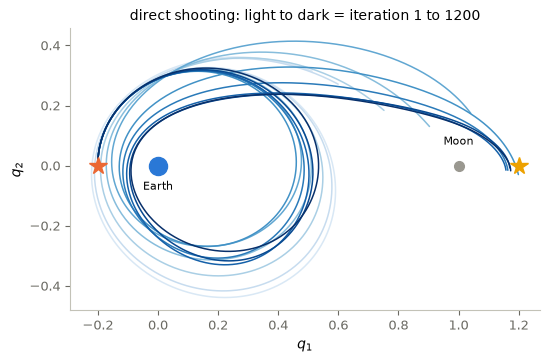

In [11]:
fig, ax = P.panels(figsize=(5.6, 4.6))
for i, xs in enumerate(snaps):
    ax.plot(xs[:, 0], xs[:, 1], color=plt.get_cmap("Blues")(0.15 + 0.85 * i / (len(snaps) - 1)), lw=1.1)
ax.plot(*qE, "o", ms=13, color=P.BLUE); ax.plot(*qM, "o", ms=7, color=P.GREY)
ax.plot(*x0[:2], "*", ms=13, color=P.ORANGE); ax.plot(*q_star, "*", ms=13, color=P.YELLOW)
ax.text(0, -0.08, "Earth", ha="center", fontsize=8); ax.text(1.0, 0.07, "Moon", ha="center", fontsize=8)
P.label(ax, "$q_1$", "$q_2$", "direct shooting: light to dark = iteration 1 to 1200", equal=True)
plt.show()

In [12]:
traj = snaps[-1][::6]

def bodies(ax):                                 # Earth and Moon, fixed in the frame
    ax.plot(*qE, "o", ms=13, color=P.BLUE); ax.plot(*qM, "o", ms=7, color=P.GREY)

P.animate_trajectory(traj, decorate=bodies, figsize=(5.0, 4.2),
                   title=lambda k: f"$t = {k * 6 * dt:.2f}$")

## 7. Markov decision processes

**Idea.** A transition probability replaces the deterministic next-state map.

Everything so far was deterministic: $f$ was a map, and the only randomness was the agent's own
exploration. Real environments are noisy, and the standard object is the **Markov decision process**, a
tuple $\mathcal{M} = (\mathcal{S}, \mathcal{A}, P, r, \gamma)$:

- a measurable state space $(\mathcal{S}, \mathcal{F}_\mathcal{S})$ and action space $(\mathcal{A}, \mathcal{F}_\mathcal{A})$;
- a **transition kernel** $P : \mathcal{S}\times\mathcal{A} \to \mathcal{P}(\mathcal{S})$, where
  $P(\cdot\mid s,a)$ is a probability measure and $(s,a)\mapsto P(B\mid s,a)$ is measurable for every
  $B \in \mathcal{F}_\mathcal{S}$:
  $$P(B \mid s,a) = \mathbb{P}\big(S_{t+1}\in B \mid S_t = s,\, A_t = a\big);$$
- a measurable **reward** $r(s,a) = \mathbb{E}[R_{t+1}\mid S_t = s, A_t = a]$;
- a discount $\gamma \in [0,1)$.

The defining assumption is the **Markov property**: for every measurable $B \subseteq \mathcal{S}$,

$$\mathbb{P}\big(S_{t+1} \in B \mid S_0,A_0,\dots,S_t,A_t\big) = P(B\mid S_t,A_t),$$

the future depends on the past only through the present state and action. A **policy** is a kernel
$\pi : \mathcal{S}\to\mathcal{P}(\mathcal{A})$, and the value functions are

$$V^\pi(s) := \mathbb{E}^\pi_s\Big[\sum_{t\ge0}\gamma^t R_{t+1}\Big],
\qquad Q^\pi(s,a) := \mathbb{E}^\pi\Big[\sum_{t\ge0}\gamma^t R_{t+1} \,\Big|\, S_0 = s, A_0 = a\Big].$$

Everything proved in §3 goes through with $V(f(x,u))$ replaced by an integral:

$$V^\star(s) = \sup_{a\in\mathcal{A}}\Big\{ r(s,a) + \gamma\int_\mathcal{S} V^\star(s')\,P(ds'\mid s,a)\Big\}.$$

The contraction proof is unchanged — an integral against a probability measure is an average, and averaging
is a non-expansion in $\lVert\cdot\rVert_\infty$ — so value iteration still converges at rate $\gamma$.

| | **Deterministic (§3–§6)** | **Probabilistic (§7–§9)** |
|---|---|---|
| Dynamics | $s_{t+1} = f(s_t,a_t)$ | $S_{t+1}\sim P(\cdot\mid S_t,A_t)$ |
| Policy | $a_t = \pi(s_t)$ | $A_t \sim \pi(\cdot\mid S_t)$ |
| Reward | $r(s_t,a_t)$ | $r(s,a) = \mathbb{E}[R_{t+1}\mid S_t=s,A_t=a]$ |
| Value | $V^\pi(s) = \sum_{t\ge0}\gamma^t r(s_t,a_t)$ | $V^\pi(s) = \mathbb{E}^\pi_s\big[\sum_{t\ge0}\gamma^t R_{t+1}\big]$ |
| Bellman | $V^\star(s) = \sup_a\{r + \gamma V^\star(f(s,a))\}$ | $V^\star(s) = \sup_a\{r + \gamma\!\int V^\star dP\}$ |

Note that a *stochastic* policy is now a first-class object rather than an exploration hack. For an MDP
with full state observation under standard assumptions, such as finite state and action spaces with bounded rewards, there is a deterministic optimal policy, so the randomness buys nothing
at the optimum — but it is what makes $\pi_\theta$ differentiable, which is the whole of the next section.

## 8. The policy gradient theorem

**Idea.** Improve a stochastic policy using sampled rewards.

Value-based methods detour through $Q$ and then take an $\arg\max$, which is awkward when $\mathcal{A}$ is
continuous: the greedy step becomes an optimization problem of its own, solved at every time step.
Policy-based methods remove the detour. Parametrise $\pi_\theta(a\mid s)$ and do gradient ascent on

$$J(\theta) := \mathbb{E}_{\tau\sim p_\theta}\big[G(\tau)\big], \qquad G(\tau) := \sum_{k\ge0}\gamma^k R_{k+1},$$

where the trajectory $\tau = (S_0,A_0,S_1,A_1,\dots)$ has density

$$p_\theta(\tau) = \nu(S_0)\prod_{t\ge0}\pi_\theta(A_t\mid S_t)\,P(S_{t+1}\mid S_t,A_t).$$

The difficulty is that $\theta$ changes the *distribution* being averaged over, not the integrand, and we
cannot differentiate $P$ because we do not know it.

> **Theorem: Policy Gradient** ([Sutton et al., 2000](https://proceedings.neurips.cc/paper/1999/hash/464d828b85b0bed98e80ade0a5c43b0f-Abstract.html)).
>
> $$\nabla_\theta J(\theta) = \mathbb{E}_{\tau\sim p_\theta}\Big[\sum_{t\ge0}\gamma^t\,
> \nabla_\theta\log\pi_\theta(A_t\mid S_t)\; Q^{\pi_\theta}(S_t,A_t)\Big].$$

*Proof sketch.* **(1) The score trick.** Assume the policy is differentiable and the derivative can be passed under the expectation (bounded returns alone do not guarantee this). Then then $\nabla_\theta p_\theta = p_\theta \nabla_\theta \log p_\theta$:

$$\nabla_\theta J = \int G(\tau)\,p_\theta(\tau)\,\nabla_\theta \log p_\theta(\tau)\,d\tau
= \mathbb{E}_\tau\big[G(\tau)\,\nabla_\theta\log p_\theta(\tau)\big].$$

Taking logs of the factorisation, $\nu$ and $P$ are free of $\theta$ and drop out:
$\nabla_\theta \log p_\theta(\tau) = \sum_{t\ge0}\nabla_\theta\log\pi_\theta(A_t\mid S_t)$. **The unknown
dynamics have disappeared** — this is the step that makes the whole method possible.

**(2) The score is centered.** For every fixed $s$,
$\mathbb{E}_{a\sim\pi_\theta}[\nabla_\theta\log\pi_\theta(a\mid s)] = \nabla_\theta\!\int \pi_\theta(a\mid s)\,da = \nabla_\theta 1 = 0.$

**(3) Causality.** Let $\mathcal{F}_t = \sigma(S_0,A_0,R_1,\dots,R_t,S_t)$, the history *before* $A_t$. For
$k < t$ the reward $R_{k+1}$ is $\mathcal{F}_t$-measurable, so by the tower property and step (2),

$$\mathbb{E}\big[R_{k+1}\nabla_\theta\log\pi_\theta(A_t\mid S_t)\big]
= \mathbb{E}\big[R_{k+1}\underbrace{\mathbb{E}[\nabla_\theta\log\pi_\theta(A_t\mid S_t)\mid\mathcal{F}_t]}_{=\,0}\big] = 0 .$$

An action cannot affect a reward that has already been paid, so only $k\ge t$ survives.

**(4) Markov.** With $\mathcal{G}_t = \sigma(\mathcal{F}_t, A_t)$, the law of the future given $\mathcal{G}_t$
depends on the history only through $(S_t,A_t)$, hence
$\mathbb{E}[\sum_{k\ge t}\gamma^{k-t}R_{k+1}\mid\mathcal{G}_t] = Q^{\pi_\theta}(S_t,A_t)$.

**(5) Assemble.** Factor $\gamma^k = \gamma^t\gamma^{k-t}$ and apply the tower with $\mathcal{G}_t$, pulling
out the $\mathcal{G}_t$-measurable score. Summing over $t$ gives the theorem. $\square$

### REINFORCE

$Q^{\pi_\theta}$ is unknown, but by definition it is the conditional mean of the realized return, so along
a sampled rollout $G_t = \sum_{k\ge0}\gamma^k r_{t+k+1}$ is an unbiased estimate of it. Substituting gives
[Williams' REINFORCE (1992)](https://doi.org/10.1007/BF00992696):

1. roll out $\{s_t,a_t,r_{t+1}\}_{t=0}^{T}$ with $a_t\sim\pi_\theta(\cdot\mid s_t)$;
2. form the returns-to-go $G_t$;
3. ascend: $\theta \leftarrow \theta + \eta\sum_t \gamma^t\,\nabla_\theta\log\pi_\theta(a_t\mid s_t)\,G_t$.

Unbiased, and badly behaved: $G_t$ sums an entire trajectory, so its variance grows with the horizon.
The standard repair is a **baseline** — replace $G_t$ by $G_t - b(s_t)$ for any function of the state alone.
Step (2) of the proof shows this changes nothing in expectation, while it can reduce the variance a great
deal. Below we center and scale the sampled returns within a batch for a compact demonstration. Because the batch mean includes each sample’s own return, this practical estimator differs from the exactly unbiased state-baseline estimator above. The code also omits the outer $\gamma^t$ weight, so it illustrates a common policy-gradient surrogate rather than the exact discounted-gradient formula.

> **Example (scalar LQ, a test with a known answer).** Take $\dot x = u$, Euler-stepped with $\Delta t = 0.1$,
> running cost $(x^2 + 0.1\,u^2)\,\Delta t$ and discount $\gamma = e^{-\rho\Delta t}$, $\rho = 0.5$. The value
> function is $V(x) = p\,x^2$, where $p$ is the fixed point of the Bellman backup of §3,
>
> $$p \;\leftarrow\; \min_{k}\Big\{(1 + 0.1\,k^2)\,\Delta t + \gamma\,p\,(1 + k\Delta t)^2\Big\},
> \qquad k = -\frac{\gamma p}{0.1 + \gamma p\,\Delta t}\ \text{the minimizer},$$
>
> and the optimal feedback is $u = \theta^\star x$ with $\theta^\star$ the minimizer at the fixed point
> (Appendix A: what it becomes as $\Delta t \to 0$). Take the policy $\pi_\theta(u \mid x) = \mathcal{N}(\theta x, \sigma^2)$.
> REINFORCE sees only states, actions and costs, yet $\theta$ should approach $\theta^\star$.

**Code and plot.** Learn a scalar feedback gain and compare it with a gain computed from the known model.

In [13]:
A_LQ, B_LQ, Q_LQ, R_LQ, RHO = 0.0, 1.0, 1.0, 0.1, 0.5

def gain(p, dt):                                                  # the minimiser, u = gain * x
    g = np.exp(-RHO * dt)
    return -g * p * B_LQ * (1 + A_LQ * dt) / (R_LQ + g * p * B_LQ ** 2 * dt)

def p_discrete(dt):                                               # fixed point of the Delta-t backup
    g, p = np.exp(-RHO * dt), 0.0
    for _ in range(int(60 / dt)):
        k = gain(p, dt)
        p = (Q_LQ + R_LQ * k ** 2) * dt + g * p * (1 + (A_LQ + B_LQ * k) * dt) ** 2
    return p

DT, T_EP, SIGMA, BATCH = 0.1, 100, 0.3, 32
GAMMA_C = float(np.exp(-RHO * DT))
theta_star = gain(p_discrete(DT), DT)                            # the optimal gain of the discretised problem

torch.set_default_dtype(torch.float32)
theta = torch.zeros(1, requires_grad=True)
opt = torch.optim.Adam([theta], lr=3e-2)
theta_hist, ret_hist = [], []

for ep in range(800):
    x, logp, rew = torch.randn(BATCH), [], []
    for t in range(T_EP):                                        # one batch of rollouts
        d = Normal(theta * x, SIGMA)
        u = d.sample()
        logp.append(d.log_prob(u)); rew.append(-(Q_LQ * x ** 2 + R_LQ * u ** 2) * DT)
        x = x + DT * u
    logp, rew = torch.stack(logp), torch.stack(rew)
    G, g = torch.zeros_like(rew), 0.0
    for t in reversed(range(T_EP)):                              # returns-to-go
        g = rew[t] + GAMMA_C * g; G[t] = g
    adv = (G - G.mean(1, keepdim=True)) / (G.std() + 1e-8)       # baseline, then rescale
    loss = -(logp * adv).sum(0).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    theta_hist.append(theta.item()); ret_hist.append(G[0].mean().item())

print(f"REINFORCE  theta = {theta.item():.4f}      optimal gain = {theta_star:.4f}")

REINFORCE  theta = -2.5740      optimal gain = -2.4951


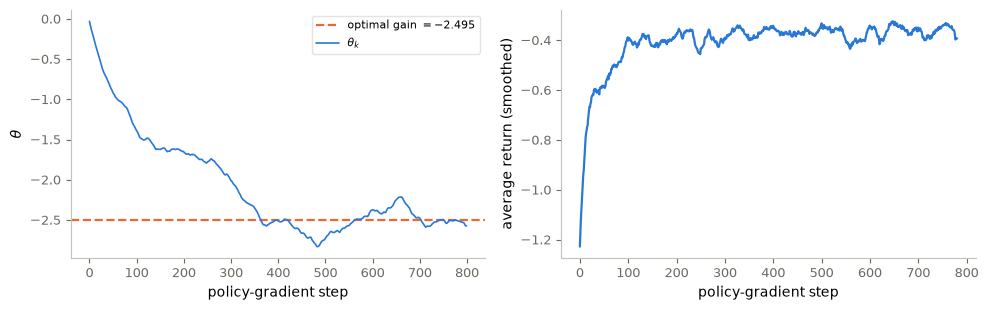

In [14]:
fig, (a0, a1) = P.panels(2, size=(5.0, 3.2))
a0.axhline(theta_star, ls="--", color=P.ORANGE, label=rf"optimal gain $= {theta_star:.3f}$")
P.curves(a0, None, {r"$\theta_k$": (theta_hist, {"color": P.BLUE, "lw": 1.2})},
       xlabel="policy-gradient step", ylabel=r"$\theta$")
P.curves(a1, None, P.smooth(ret_hist, 20), xlabel="policy-gradient step",
       ylabel="average return (smoothed)")
plt.show()

## 9. Proximal Policy Optimization

**Idea.** Use a critic and clipped policy ratios to update from one rollout batch.

**Optional training extension.** REINFORCE has two defects. Its gradient estimate is noisy, and each batch of data can be used for exactly
one step — after the update the data is off-policy and the estimator is no longer valid. PPO
([Schulman et al., 2017](https://arxiv.org/abs/1707.06347)) repairs both, and in doing so became the
default algorithm for continuous control and, later, for aligning language models.

**A critic, to reduce variance.** Train a value network $V_\phi$ alongside the policy. From the
temporal-difference residuals $\delta_t = r_{t+1} + \gamma V_\phi(s_{t+1}) - V_\phi(s_t)$, form the
*generalized advantage estimate* ([Schulman et al., 2016](https://arxiv.org/abs/1506.02438))

$$A_t := \sum_{l\ge0}(\gamma\lambda)^l\,\delta_{t+l},$$

which interpolates between $\lambda = 0$ (one-step TD: low variance, biased by the critic's error) and
$\lambda = 1$ (the Monte-Carlo return minus a baseline: unbiased, high variance). It answers "how much
better was $a_t$ than what the critic expected of this state?". The critic is fitted to its own targets,
$L^{\text{VF}} = \mathbb{E}_t[(V_\phi(s_t) - R_t)^2]$ with $R_t = A_t + V_\phi(s_t)$.

**A clip, to reuse the batch.** Importance sampling lets a batch drawn under $\pi_{\theta_{\text{old}}}$
estimate the objective at a nearby $\theta$, through the ratio
$\varrho_t(\theta) = \pi_\theta(a_t\mid s_t)/\pi_{\theta_{\text{old}}}(a_t\mid s_t)$ — but only while the two
policies are close, since the variance of the estimate blows up with the ratio. PPO discourages large changes
by clipping the policy ratio in a surrogate objective:

$$L^{\text{CLIP}}(\theta) = \mathbb{E}_t\Big[\min\big(\varrho_t A_t,\;\mathrm{clip}(\varrho_t, 1-\epsilon, 1+\epsilon)A_t\big)\Big].$$

If $A_t > 0$ the objective stops rewarding increases in $\varrho_t$ beyond $1+\epsilon$; if $A_t<0$ it stops
rewarding decreases below $1-\epsilon$. For these favorable changes beyond the clip, the clipped contribution has zero gradient. The $\min$ retains penalties for changes that worsen the sampled advantage. This permits several optimization epochs on one rollout batch, but clipping is a heuristic: it does not impose a hard bound on the policy change or guarantee improved return.

**An entropy bonus, to keep exploring.** $\mathcal{H}[\pi_\theta] = -\mathbb{E}_{a\sim\pi_\theta}[\log \pi_\theta(a\mid s)]$
rewards keeping the action distribution broad. Unlike $\varepsilon$-greedy, it is part of the objective and
differentiable, so the policy decides for itself how much noise to keep. The full loss is

$$\mathcal{L} = -L^{\text{CLIP}} + c_1 L^{\text{VF}} - c_2\,\mathcal{H}[\pi_\theta].$$

### A pendulum that must swing itself up

This is a pendulum swing-up task, as in [notebook 02](02_control_theory.ipynb), where MPC uses known dynamics. The numerical models and torque limits differ, so the examples are qualitative comparisons.
Here the agent gets $(\cos\theta,\sin\theta,\dot\theta/8)$, a torque bounded by $\lvert u \rvert \le 2$ — too weak to lift
the pendulum directly, so it must pump energy by rocking — and the reward

$$r = -\big(\bar\theta^2 + 0.1\,\dot\theta^2 + 0.001\,u^2\big),$$

with $\theta = 0$ upright. It is told nothing else: not that $\theta$ is an angle, not that energy is
conserved, not that swinging is necessary.

**Code and plot.** This longer training example shows the clipped update on pendulum rollouts.

In [15]:
G_ACC, L_ROD, M_ROD, DT_P, U_MAX = 9.81, 1.0, 1.0, 0.05, 2.0

def step(s, u):                                            # s = (theta, theta_dot), batched
    th, w = s[:, 0], s[:, 1]
    w = (w + DT_P * (1.5 * G_ACC / L_ROD * torch.sin(th)
                     + 3.0 * u.clamp(-U_MAX, U_MAX).squeeze(-1) / (M_ROD * L_ROD ** 2))).clamp(-8, 8)
    return torch.stack([th + DT_P * w, w], 1)

def obs(s):
    return torch.stack([torch.cos(s[:, 0]), torch.sin(s[:, 0]), s[:, 1] / 8], 1)

def reward(s, u):
    th = (s[:, 0] + np.pi) % (2 * np.pi) - np.pi           # 0 = upright
    return -(th ** 2 + 0.1 * s[:, 1] ** 2 + 0.001 * u.squeeze(-1) ** 2)

In [16]:
NENV, HOR, GAM, LAM, EPS_CLIP, K_EPOCH = 64, 200, 0.99, 0.95, 0.2, 10
mlp = lambda: nn.Sequential(nn.Linear(3, 64), nn.Tanh(), nn.Linear(64, 64), nn.Tanh(), nn.Linear(64, 1))
actor, critic, log_std = mlp(), mlp(), nn.Parameter(torch.zeros(1))
opt = torch.optim.Adam([*actor.parameters(), *critic.parameters(), log_std], lr=3e-3)

returns = []
for it in range(300):
    s = torch.stack([torch.rand(NENV) * 2 * np.pi - np.pi, torch.rand(NENV) * 2 - 1], 1)
    O, U, LP, R_, V_ = [], [], [], [], []
    with torch.no_grad():                                           # rollout under pi_old
        for t in range(HOR):
            o = obs(s); d = Normal(actor(o), log_std.exp()); u = d.sample()
            O.append(o); U.append(u); LP.append(d.log_prob(u).sum(-1)); V_.append(critic(o).squeeze(-1))
            R_.append(reward(s, u)); s = step(s, u)
        V_.append(critic(obs(s)).squeeze(-1))
    O, U, LP, R_, V_ = map(torch.stack, (O, U, LP, R_, V_))

    adv, g = torch.zeros(HOR, NENV), 0.0                            # generalised advantage estimate
    for t in reversed(range(HOR)):
        g = R_[t] + GAM * V_[t + 1] - V_[t] + GAM * LAM * g; adv[t] = g
    ret = adv + V_[:-1]
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)
    O, U = O.reshape(-1, 3), U.reshape(-1, 1)
    LP, adv, ret = LP.reshape(-1), adv.reshape(-1), ret.reshape(-1)

    for _ in range(K_EPOCH):                                        # reuse the batch K times
        d = Normal(actor(O), log_std.exp())
        rho = (d.log_prob(U).sum(-1) - LP).exp()
        clip = torch.min(rho * adv, rho.clamp(1 - EPS_CLIP, 1 + EPS_CLIP) * adv).mean()
        loss = -clip + 0.5 * ((critic(O).squeeze(-1) - ret) ** 2).mean() - 0.001 * d.entropy().sum(-1).mean()
        opt.zero_grad(); loss.backward(); opt.step()

    returns.append(R_.sum(0).mean().item())
    if it % 30 == 0:
        print(f"iteration {it:4d}:  average return = {returns[-1]:8.1f}")
print(f"final (mean of last 10): {np.mean(returns[-10:]):.1f}")

iteration    0:  average return =  -1253.6


iteration   30:  average return =   -845.9


iteration   60:  average return =   -216.3


iteration   90:  average return =   -178.7


iteration  120:  average return =   -185.6


...

iteration  180:  average return =   -150.8


iteration  210:  average return =   -163.4


iteration  240:  average return =   -149.7


iteration  270:  average return =   -146.9


final (mean of last 10): -153.3


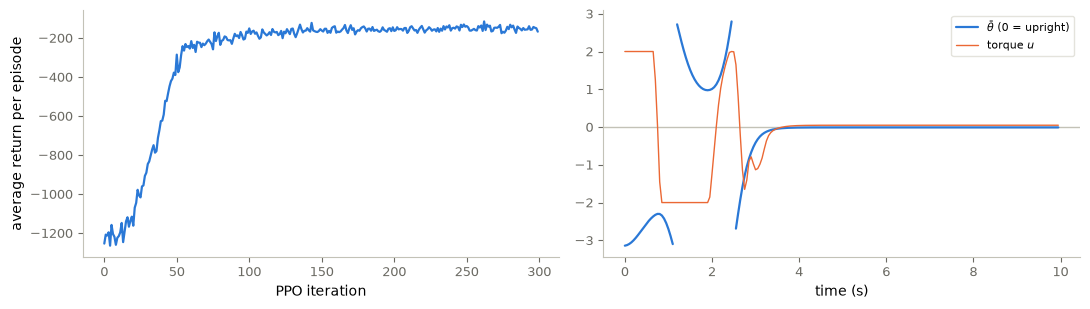

In [17]:
s, traj = torch.tensor([[np.pi, 0.0]]), []                 # hanging straight down, at rest
with torch.no_grad():
    for t in range(200):
        u = actor(obs(s))                                  # the mean action: no exploration noise
        traj.append([s[0, 0].item(), s[0, 1].item(), u.item()]); s = step(s, u)
traj = np.array(traj)

fig, (a0, a1) = P.panels(2, size=(5.5, 3.2))
P.curves(a0, None, returns, xlabel="PPO iteration", ylabel="average return per episode")
tt = np.arange(200) * DT_P
th = P.cut_jumps((traj[:, 0] + np.pi) % (2 * np.pi) - np.pi)        # hide the jump at the wrap
P.curves(a1, tt, {r"$\bar\theta$ (0 = upright)": (th, P.BLUE),
                "torque $u$": (traj[:, 2].clip(-U_MAX, U_MAX), {"color": P.ORANGE, "lw": 1})},
       xlabel="time (s)", zero="h")
plt.show()

In [18]:
P.animate_pendulum(traj[:, 0], dt=DT_P, frames=np.arange(0, 200, 2), figsize=(3.6, 3.6))

## 10. What we left out

**Idea.** The examples introduce a few tools; realistic tasks combine them with further assumptions.


**Other things worth a notebook of their own.** *Model-based RL* learns $f$ and $r$ from data and then
plans against them — drop the neural ODE of notebook 04 into the place where MPC expects its model, and
that is the whole idea. *Inverse RL* infers $r$ from expert demonstrations; *imitation learning* skips $r$
and copies the expert directly. *Multi-agent* RL puts several learners in one environment, where the
stationarity the Markov property assumes is gone. *Meta-RL* learns across a family of environments.

**The difficulties, stated plainly.**

- *Exploration.* The $\varepsilon$-greedy rule of §5 is a placeholder. In a long-horizon task with a single
  reward at the end, random actions essentially never find it.
- *Credit assignment.* When the reward arrives a thousand steps after the decision that caused it, $\gamma^t$
  has already made the signal negligible.
- *Sample efficiency.* The pendulum above cost millions of steps for a problem a controls engineer solves
  with a pen. This is tolerable in a simulator and often prohibitive on hardware.
- *Reward design and reward hacking.* The agent optimizes what you wrote, not what you meant. The
  $0.001\,u^2$ term in the pendulum reward is there to stop it chattering the torque; remove it and watch.
- *Instability.* Seeds, reward scaling and learning rates change results more than algorithmic choices do.
  Published comparisons are frequently within seed noise.

**MPC or RL?** It is not a competition so much as a question of where you want to spend. MPC needs a model
and online computation, and gives constraint satisfaction, stability certificates and immediate
adaptation to a new cost. RL needs data and offline computation, and gives a policy that is cheap to
evaluate and does not care how nasty the dynamics are. The interesting work is in between: *data-driven
MPC*, which learns the model and keeps the guarantees, and *model-based RL*, which plans against a learned
model. The practical question is how much useful information each interaction provides.

**And the mathematics we only touched.** Viscosity solutions of the HJB equation (Appendix A); convergence rates of
stochastic approximation; the geometry behind the trust region in PPO (natural gradients and TRPO);
continuous-time RL, where the Bellman backup becomes an SDE problem and recent work is actively reopening
the question; and the fact that score-based diffusion sampling is itself a stochastic optimal control
problem, whose optimal control turns out to be the score — which is the starting point of notebook 05.

## Key takeaways

- The Bellman equation expresses a decision as immediate reward plus future value.
- Value iteration uses a model; Q-learning estimates action values from observed transitions.
- Exploration provides information about actions the current policy would otherwise avoid.
- Policy gradients improve a parameterized policy using sampled returns; PPO adds a critic and a clipped surrogate.

## Exercises

1. **Discounting.** Run value iteration with `GAMMA = 0.5` and `GAMMA = 0.99`. Compare how far the goal’s value propagates through the maze.
2. **Exploration.** Compare the bandit curves for `eps = 0`, `0.01`, and `0.1`. Which rule earns more reward early and late?
3. **Learning from samples.** Change the Q-learning step size from `0.2` to `0.05`. Plot the error against environment steps and explain the trade-off.

## References

**Origins**

1. E. L. Thorndike, [*Animal Intelligence: An Experimental Study of the Associative Processes in Animals*](https://psychclassics.yorku.ca/Thorndike/Animal/),
   Psychological Review Monograph Supplement **2** (1898).
2. B. F. Skinner, [*The Behavior of Organisms: An Experimental Analysis*](https://doi.org/10.1037/h0058412), Appleton-Century, 1938.
3. H. Robbins, [*Some aspects of the sequential design of experiments*](https://doi.org/10.1090/S0002-9904-1952-09620-8), Bulletin of the AMS **58** (1952),
   527–535.
4. R. Bellman, [*On the theory of dynamic programming*](https://doi.org/10.1073/pnas.38.8.716), PNAS **38** (1952), 716–719.
5. R. Bellman, [*Dynamic Programming*](https://doi.org/10.1515/9781400835386), Princeton University Press, 1957 (linked 2010 reprint).
6. R. A. Howard, [*Dynamic Programming and Markov Processes*](https://www.ronhoward.org/pure-ron/bibliography), MIT Press, 1960.
7. L. S. Pontryagin, V. G. Boltyanskii, R. V. Gamkrelidze, E. F. Mishchenko, [*The Mathematical Theory of
   Optimal Processes*](https://www.routledge.com/The-Mathematical-Theory-of-Optimal-Processes/Pontryagin/p/book/9782881240775), Interscience, 1962 (linked 1987 reprint).
8. M. G. Crandall, P.-L. Lions, [*Viscosity solutions of Hamilton–Jacobi equations*](https://doi.org/10.1090/S0002-9947-1983-0690039-8), Transactions of the AMS
   **277** (1983), 1–42.

**Reinforcement learning**

9. R. S. Sutton, [*Learning to predict by the methods of temporal differences*](https://doi.org/10.1007/BF00115009), Machine Learning **3**
   (1988), 9–44.
10. C. J. C. H. Watkins, [*Learning from Delayed Rewards*](https://www.repository.cam.ac.uk/items/f1ce2aa9-2e01-4a08-92b7-1eec76b652ed), PhD thesis, University of Cambridge, 1989.
11. C. J. C. H. Watkins, P. Dayan, [*Q-learning*](https://doi.org/10.1007/BF00992698), Machine Learning **8** (1992), 279–292.
12. R. J. Williams, [*Simple statistical gradient-following algorithms for connectionist reinforcement
    learning*](https://doi.org/10.1007/BF00992696), Machine Learning **8** (1992), 229–256.
13. W. Schultz, P. Dayan, P. R. Montague, [*A neural substrate of prediction and reward*](https://doi.org/10.1126/science.275.5306.1593), Science **275**
    (1997), 1593–1599.
14. R. S. Sutton, D. McAllester, S. Singh, Y. Mansour, [*Policy gradient methods for reinforcement learning
    with function approximation*](https://proceedings.neurips.cc/paper/1999/hash/464d828b85b0bed98e80ade0a5c43b0f-Abstract.html), NeurIPS, 2000.
15. R. S. Sutton, A. G. Barto, [*Reinforcement Learning: An Introduction*](https://mitpress.mit.edu/9780262039246/reinforcement-learning/), 2nd ed., MIT Press, 2018.

**Deep reinforcement learning**

16. V. Mnih et al., [*Human-level control through deep reinforcement learning*](https://doi.org/10.1038/nature14236), Nature **518** (2015),
    529–533.
17. D. Silver et al., [*Mastering the game of Go with deep neural networks and tree search*](https://doi.org/10.1038/nature16961), Nature **529**
    (2016), 484–489.
18. J. Schulman, P. Moritz, S. Levine, M. Jordan, P. Abbeel, [*High-dimensional continuous control using
    generalized advantage estimation*](https://arxiv.org/abs/1506.02438), ICLR, 2016.
19. J. Schulman, F. Wolski, P. Dhariwal, A. Radford, O. Klimov, [*Proximal policy optimization algorithms*](https://arxiv.org/abs/1707.06347),
    arXiv:1707.06347, 2017.
20. T. Haarnoja, A. Zhou, P. Abbeel, S. Levine, [*Soft actor-critic: off-policy maximum entropy deep
    reinforcement learning with a stochastic actor*](https://arxiv.org/abs/1801.01290), ICML, 2018.

**Control, and the bridge back**

21. D. P. Bertsekas, [*Reinforcement Learning and Optimal Control*](https://faculty.engineering.asu.edu/bertsekas/books/reinforcement-learning-and-optimal-control), Athena Scientific, 2019.
22. D. Q. Mayne, J. B. Rawlings, C. V. Rao, P. O. M. Scokaert, [*Constrained model predictive control:
    stability and optimality*](https://doi.org/10.1016/S0005-1098(99)00214-9), Automatica **36** (2000), 789–814.
23. G. Fabbri, F. Gozzi, A. Święch, [*Stochastic Optimal Control in Infinite Dimension*](https://doi.org/10.1007/978-3-319-53067-3), Springer, 2017.
24. R. T. Q. Chen, Y. Rubanova, J. Bettencourt, D. Duvenaud, [*Neural ordinary differential equations*](https://arxiv.org/abs/1806.07366),
    NeurIPS, 2018.

## Appendix A. Continuous time: the Hamilton–Jacobi–Bellman equation

The Bellman equation of §3 describes a sequence of decisions at discrete times. A mechanical system does not
wait for them, and the equation has a continuous-time limit.

| | **Discrete time** | **Continuous time** |
|---|---|---|
| Dynamics | $x_{t+1} = f(x_t,u_t)$ | $\dot x_t = f(x_t,u_t)$ |
| Value | $V(x) = \sup \sum_{t\ge0}\gamma^t r(x_t,u_t)$ | $V(x) = \sup \int_0^\infty \gamma^t\, r(x_t,u_t)\,dt$ |
| Equation | $V(x) = \max_u \{ r + \gamma V(f(x,u))\}$ | $-\ln(\gamma)\,V(x) = \max_u \{ r(x,u) + \nabla V(x)^\top f(x,u)\}$ |

*Derivation.* Take a step of length $\Delta t$. The reward accrued is $r(x,u)\Delta t$, the discount applied
is $\gamma^{\Delta t}$, and the state moves to $x + f(x,u)\Delta t$. The discrete Bellman equation reads

$$V(x) = \max_u \Big\{ r(x,u)\Delta t + \gamma^{\Delta t}\, V\big(x + f(x,u)\Delta t\big)\Big\}.$$

Expand both the discount and the value to first order, $\gamma^{\Delta t} = 1 + \ln(\gamma)\Delta t + o(\Delta t)$
and $V(x + f\Delta t) = V(x) + \nabla V(x)^\top f \Delta t + o(\Delta t)$:

$$V(x) = \max_u \Big\{ r\Delta t + \big(1 + \ln(\gamma)\Delta t\big)\big[V(x) + \nabla V(x)^\top f\,\Delta t\big]\Big\} + o(\Delta t).$$

Cancel $V(x)$ from both sides, divide by $\Delta t$ and let $\Delta t \to 0$:

$$0 = \max_{u\in\mathcal{U}} \Big\{ r(x,u) + \nabla V(x)^\top f(x,u) + \ln(\gamma) V(x)\Big\}.$$

Writing $\gamma = e^{-\rho}$ puts it in its usual form, $\rho V = \max_u \{ r + \nabla V^\top f\}$. This is
the **Hamilton–Jacobi–Bellman** equation: a first-order, fully nonlinear PDE on the state space. Its
solutions are generally not differentiable and the right
notion is a [*viscosity solution*](https://doi.org/10.1090/S0002-9947-1983-0690039-8) ([Crandall and Lions, 1983](https://doi.org/10.1090/S0002-9947-1983-0690039-8)), for which existence and uniqueness can be established under suitable assumptions.

**A check on the scalar problem of §8.** Take $\dot x = ax + bu$ with cost $q x^2 + \mathsf{r}\,u^2$; in the cost
convention the $\max$ becomes a $\min$. Try $V(x) = p\,x^2$. The minimizer is $u = -(pb/\mathsf{r})\,x$, and the
HJB equation collapses to the algebraic Riccati equation

$$\frac{b^2}{\mathsf{r}}\,p^2 + (\rho - 2a)\,p - q = 0 .$$

Below, its positive root is compared with the fixed point `p_discrete(`$\Delta t$`)` of the discrete backup of §8, with
$a = 0$, $b = 1$, $q = 1$, $\mathsf{r} = 0.1$, $\rho = 0.5$ as there.

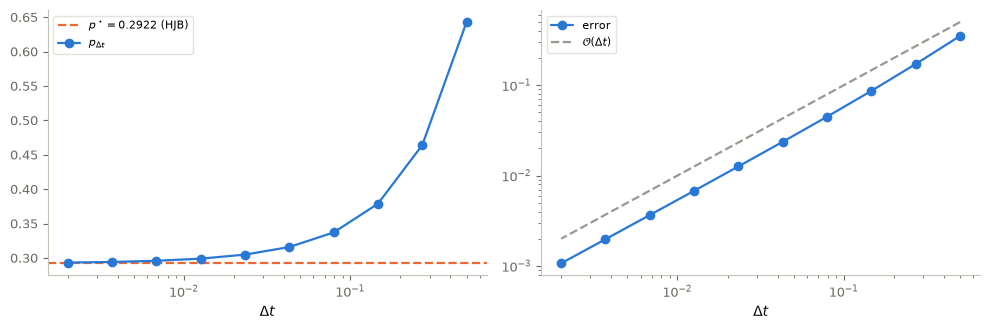

continuous-time optimal feedback:  u = -2.9221 x
its Delta t = 0.1 counterpart:     u = -2.4951 x


In [19]:
p_star = np.roots([B_LQ ** 2 / R_LQ, RHO - 2 * A_LQ, -Q_LQ]).max()          # the positive root of the Riccati equation

dts = np.geomspace(0.5, 2e-3, 10)
ps = np.array([p_discrete(dt) for dt in dts])

fig, (a0, a1) = P.panels(2, size=(5.0, 3.4))
a0.axhline(p_star, ls="--", color=P.ORANGE, label=rf"$p^\star = {p_star:.4f}$ (HJB)")
P.curves(a0, dts, {r"$p_{\Delta t}$": (ps, {"color": P.BLUE, "marker": "o"})},
       log="x", xlabel=r"$\Delta t$")
P.curves(a1, dts, {"error": (np.abs(ps - p_star), {"color": P.BLUE, "marker": "o"}),
                 r"$\mathcal{O}(\Delta t)$": (dts, {"color": P.GREY, "ls": "--"})},
       log="xy", xlabel=r"$\Delta t$")
plt.show()
print(f"continuous-time optimal feedback:  u = {-p_star * B_LQ / R_LQ:.4f} x")
print(f"its Delta t = 0.1 counterpart:     u = {gain(p_discrete(0.1), 0.1):.4f} x")

The error is first order in $\Delta t$, which is what an Euler discretization of the dynamics together with
a first-order expansion of $\gamma^{\Delta t}$ should give.

Keep the second number in mind. An agent that acts every $\Delta t = 0.1$ is solving the discrete problem,
not the continuous one, so $-2.4951$ — not $-2.9221$ — is the gain it should find. That is the target §8 hands to
REINFORCE, an algorithm that knows neither $a$, $b$, $q$ nor $\mathsf{r}$.